# Feature Analysis: Autoencoder + SVM Two-Stage Pipeline

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

from scripts.config import PROCESSED_DIR, MODEL_DIR, RANDOM_STATE
from scripts.models import create_stage1_detector, create_stage2_classifier

d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data and Train Models

In [ ]:
df_full = pd.read_csv(PROCESSED_DIR / 'full_windowed.csv')
normal_windows = pd.read_csv(PROCESSED_DIR / 'normal_windowed.csv')
eval_set = pd.read_csv(PROCESSED_DIR / 'eval_results.csv', index_col=0)

feature_cols = [col for col in df_full.columns if col not in ['window_id', 'window_attack']]

print("Training Stage 1: Autoencoder...")
autoencoder = create_stage1_detector('autoencoder')
autoencoder.fit(normal_windows[feature_cols].values)

ae_flags_eval = autoencoder.predict(eval_set[feature_cols].values)
flagged_stage2 = eval_set[ae_flags_eval == 1].copy()

X_s2 = flagged_stage2[feature_cols]
y_s2 = flagged_stage2['window_attack']

print("Training Stage 2: SVM...")
svm = create_stage2_classifier('svm')
svm.fit(X_s2, y_s2, scaler=autoencoder.scaler)

print(f"Pipeline ready. SVM trained on {len(flagged_stage2)} instances.")

Training Stage 1: Autoencoder...
Training Stage 2: SVM...
Pipeline ready. SVM trained on 801 instances.


d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### 1.1 Stage 1 Results

In [3]:
y_eval_true = eval_set['window_attack']
print("Stage 1 (Autoencoder) Classification Report:")
print(classification_report(y_eval_true, ae_flags_eval))

print(f"Total windows flagged for Stage 2: {ae_flags_eval.sum()} out of {len(eval_set)}")

Stage 1 (Autoencoder) Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       479
           1       0.94      1.00      0.97       753

    accuracy                           0.96      1232
   macro avg       0.97      0.95      0.96      1232
weighted avg       0.96      0.96      0.96      1232

Total windows flagged for Stage 2: 801 out of 1232


## 2. PCA Visualization
Visualizing how the two stages separate different types of traffic.

d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


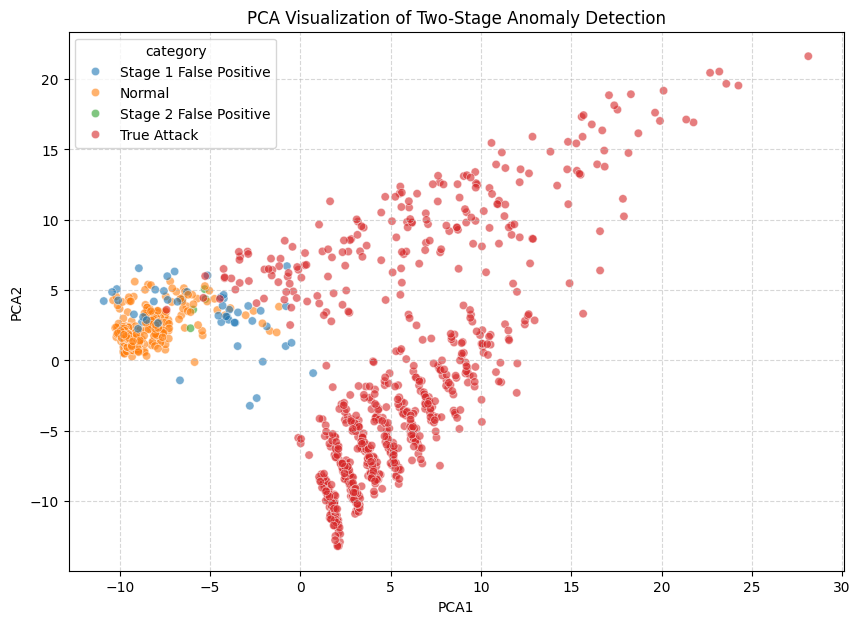

In [ ]:
scaler = autoencoder.scaler
X_eval_scaled = scaler.transform(eval_set[feature_cols])
svm_preds = svm.predict(eval_set[feature_cols])

# Categorize instances
plot_df = eval_set.copy()
plot_df['category'] = 'Normal'
plot_df.loc[(eval_set['window_attack'] == 1), 'category'] = 'True Attack'
plot_df.loc[(ae_flags_eval == 1) & (eval_set['window_attack'] == 0), 'category'] = 'Stage 1 False Positive'
plot_df.loc[(svm_preds == 1) & (eval_set['window_attack'] == 0), 'category'] = 'Stage 2 False Positive'

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_eval_scaled)
plot_df['PCA1'] = pca_results[:, 0]
plot_df['PCA2'] = pca_results[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='category', alpha=0.6)
plt.title("PCA Visualization of Two-Stage Anomaly Detection")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. SHAP Interpretation for Stage 2
Explaining why the SVM classifies certain suspicious traffic as attacks or normal.

d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
100%|██████████| 100/100 [00:08<00:00, 11.82it/s]


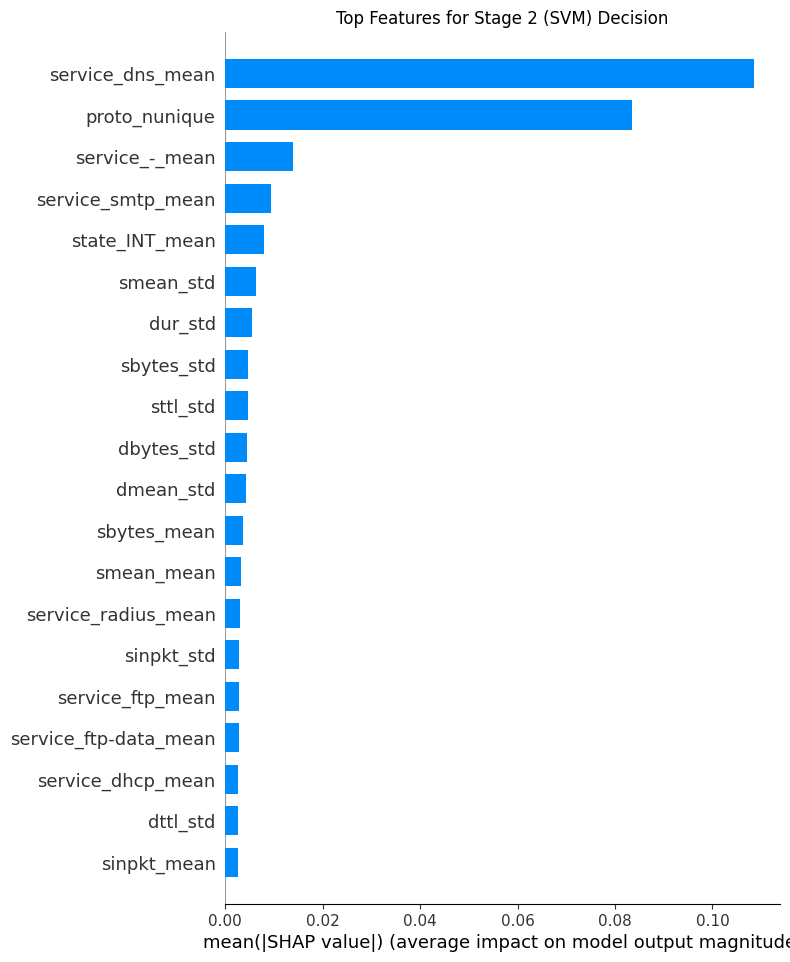

In [5]:
X_shap = scaler.transform(X_s2)
background_data = shap.sample(X_shap, 50)

explainer = shap.KernelExplainer(svm.model.predict, background_data)
shap_values = explainer.shap_values(shap.sample(X_shap, 100), nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap.sample(X_s2, 100), plot_type="bar", show=False)
plt.title("Top Features for Stage 2 (SVM) Decision")
plt.show()

## 4. Performance Evaluation

In [6]:
def pipeline_predict(X):
    s1_flags = autoencoder.predict(X)
    final_preds = np.zeros(len(X))
    if np.any(s1_flags == 1):
        final_preds[s1_flags == 1] = svm.predict(X[s1_flags == 1])
    return final_preds

y_true = eval_set['window_attack']
y_pred = pipeline_predict(eval_set[feature_cols])

print("Performance Report\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Total Windows: {len(eval_set)}")
print(f"Correctly Identified Attacks: {tp}")
print(f"Missed Attacks: {fn}")
print(f"False Alarms (Normal traffic flagged): {fp}")

Performance Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       479
           1       1.00      0.99      0.99       753

    accuracy                           0.99      1232
   macro avg       0.99      0.99      0.99      1232
weighted avg       0.99      0.99      0.99      1232

Total Windows: 1232
Correctly Identified Attacks: 743
Missed Attacks: 10
False Alarms (Normal traffic flagged): 0


d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\Sarthak\Projects\network-traffic-anomaly-analysis\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
